# Libraries

In [1]:
import os
import re
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import shapiro

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.seasonal import seasonal_decompose

# Load and Combine Dataset

In [2]:
DATA_DIR = "dataset"
files = sorted(glob.glob(os.path.join(DATA_DIR, "Inflasi Bulanan*.csv")))
for file in files:
    print(os.path.basename(file))

Inflasi Bulanan (M-to-M), 2015.csv
Inflasi Bulanan (M-to-M), 2016.csv
Inflasi Bulanan (M-to-M), 2017.csv
Inflasi Bulanan (M-to-M), 2018.csv
Inflasi Bulanan (M-to-M), 2019.csv
Inflasi Bulanan (M-to-M), 2020.csv
Inflasi Bulanan (M-to-M), 2021.csv
Inflasi Bulanan (M-to-M), 2022.csv
Inflasi Bulanan (M-to-M), 2023.csv
Inflasi Bulanan (M-to-M), 2024.csv
Inflasi Bulanan (M-to-M), 2025.csv
Inflasi Bulanan (M-to-M), 2026.csv


In [3]:
map_bulan = {
    "Januari": "01",
    "Februari": "02",
    "Maret": "03",
    "April": "04",
    "Mei": "05",
    "Juni": "06",
    "Juli": "07",
    "Agustus": "08",
    "September": "09",
    "Oktober": "10",
    "November": "11",
    "Desember": "12"
}

def bps_inflation(path, wilayah="INDONESIA"):
    df = pd.read_csv(path, header=None, encoding="utf-8-sig")
    match = re.search(r"(20\d{2})", os.path.basename(path))
    if match is None:
        raise ValueError(f"Tahun tidak ditemukan: {path}")
    
    tahun = int(match.group(1))
    header = df.index[
        df.apply(
            lambda row: row.astype(str).str.contains("Januari", case=False, na=False).any(),
            axis=1
        )
    ][0]
    header = df.iloc[header]

    mask_wilayah = df.iloc[:, 0].astype(str).str.strip().str.upper() == wilayah.upper()
    if not mask_wilayah.any():
        raise ValueError(f"Wilayah {wilayah} tidak ditemukan")
    
    data = df[mask_wilayah].iloc[0]

    dataset = []
    for col, nama_bulan in enumerate(header):
        nama_bulan = str(nama_bulan).strip()
        if nama_bulan in map_bulan:
            nilai = data.iloc[col]
            if pd.isna(nilai) or str(nilai).strip() in ["-", ""]:
                continue
            nilai = float(str(nilai).replace(",", "."))
            tanggal = pd.to_datetime(f"{tahun}-{map_bulan[nama_bulan]}-01")
            dataset.append({
                "tanggal": tanggal,
                "wilayah": wilayah,
                "inflasi": nilai
            })
    return pd.DataFrame(dataset)

## Data Cleaning

In [4]:
df_all = pd.concat(
    [bps_inflation(file, wilayah="INDONESIA") for file in files], ignore_index=True
)

df_all = df_all.drop_duplicates(subset=["tanggal", "wilayah"]).sort_values("tanggal").reset_index(drop=True)
df_all.head()

,tanggal,wilayah,inflasi
0,2015-01-01,INDONESIA,-0.24
1,2015-02-01,INDONESIA,-0.36
2,2015-03-01,INDONESIA,0.17
3,2015-04-01,INDONESIA,0.36
4,2015-05-01,INDONESIA,0.50


In [5]:
df = df_all[
    (df_all["tanggal"] >= "2015-01-01") & (df_all["tanggal"] <= "2025-12-01")
].copy()

df = df.set_index("tanggal")
df = df.asfreq("MS")

df.to_csv("dataset/inflasi_indonesia_2015_2025_clean.csv")
df.head()

,wilayah,inflasi
tanggal,,
2015-01-01,INDONESIA,-0.24
2015-02-01,INDONESIA,-0.36
2015-03-01,INDONESIA,0.17
2015-04-01,INDONESIA,0.36
2015-05-01,INDONESIA,0.50


# Exploratory Data Analysis

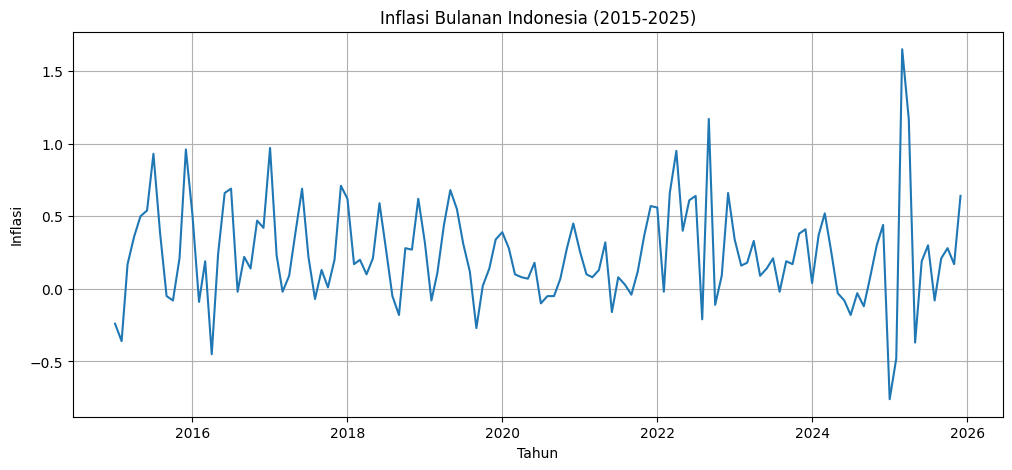

In [6]:
plt.figure(figsize=(12,5))
plt.plot(df.index, df["inflasi"])
plt.title("Inflasi Bulanan Indonesia (2015-2025)")
plt.xlabel("Tahun")
plt.ylabel("Inflasi")
plt.grid(True)
plt.show()

## Rolling Mean and Standard Deviation

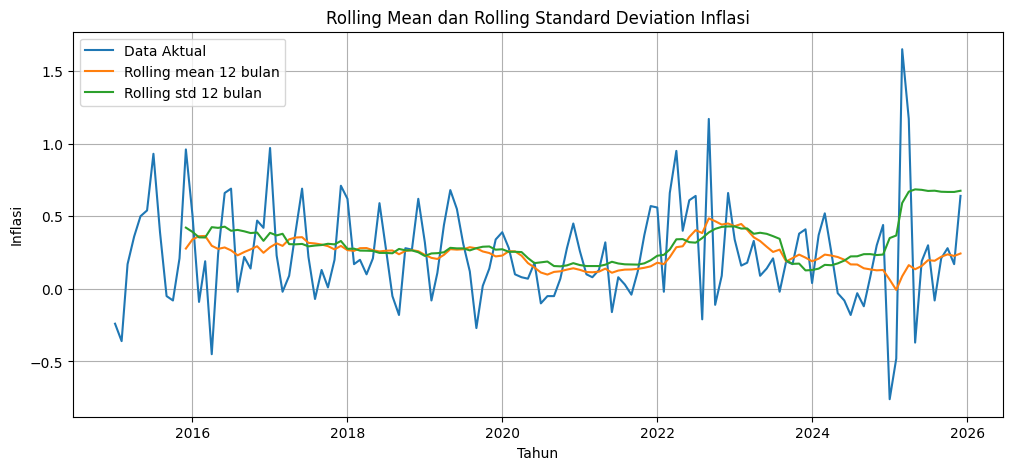

In [7]:
rolling_mean = df["inflasi"].rolling(window=12).mean()
rolling_std = df["inflasi"].rolling(window=12).std()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df["inflasi"], label="Data Aktual")
plt.plot(rolling_mean.index, rolling_mean, label="Rolling mean 12 bulan")
plt.plot(rolling_std.index, rolling_std, label="Rolling std 12 bulan")

plt.title("Rolling Mean dan Rolling Standard Deviation Inflasi")
plt.xlabel("Tahun")
plt.ylabel("Inflasi")
plt.legend()
plt.grid(True)
plt.show()

## Seasonal Decomposition

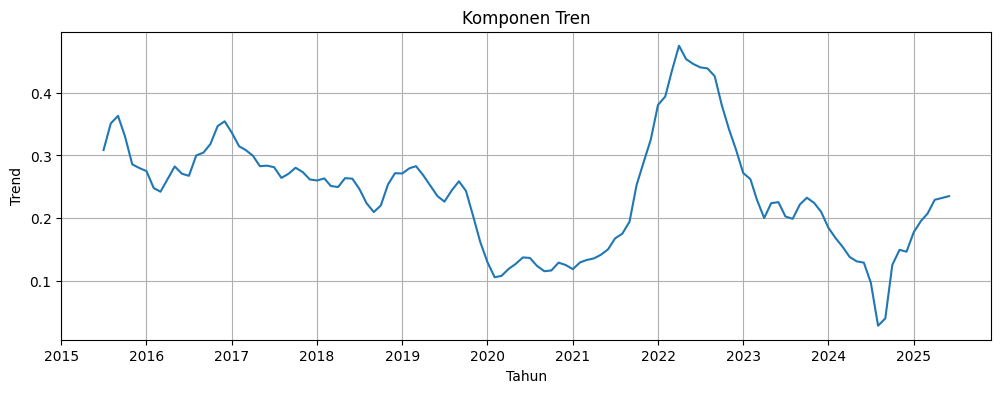

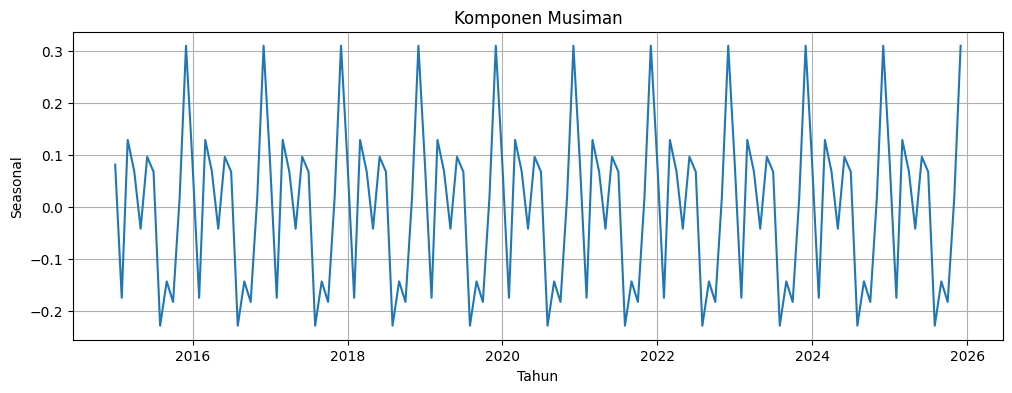

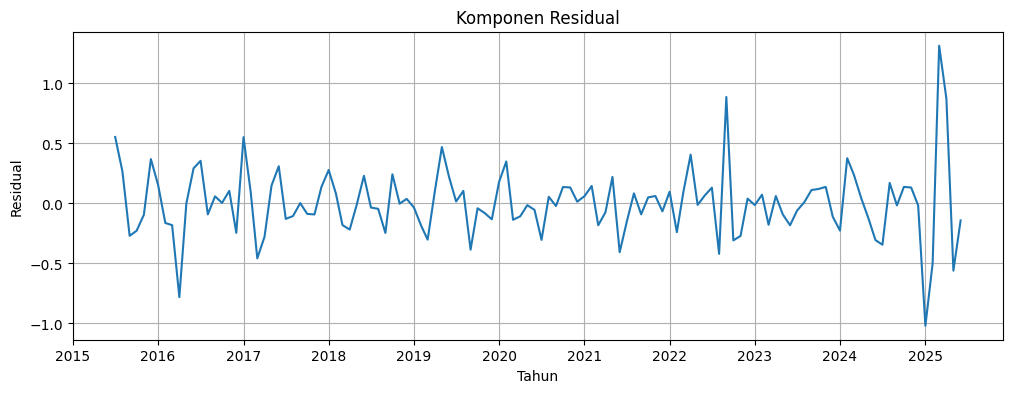

In [8]:
decomposition = seasonal_decompose(
    df["inflasi"],
    model="additive",
    period=12
)

plt.figure(figsize=(12, 4))
plt.plot(decomposition.trend)
plt.title("Komponen Tren")
plt.xlabel("Tahun")
plt.ylabel("Trend")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(decomposition.seasonal)
plt.title("Komponen Musiman")
plt.xlabel("Tahun")
plt.ylabel("Seasonal")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(decomposition.resid)
plt.title("Komponen Residual")
plt.xlabel("Tahun")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

# Train-Test Split

In [9]:
y = df["inflasi"]
df_train = y.loc["2015-01-01":"2024-12-01"]
df_test = y.loc["2025-01-01":"2025-12-01"]

print("Jumlah train:", len(df_train))
print("Jumlah test:", len(df_test))
print("Periode train:", df_train.index.min(), "-", df_train.index.max())
print("Periode test:", df_test.index.min(), "-", df_test.index.max())

Jumlah train: 120
Jumlah test: 12
Periode train: 2015-01-01 00:00:00 - 2024-12-01 00:00:00
Periode test: 2025-01-01 00:00:00 - 2025-12-01 00:00:00


# Stationarity Test

In [10]:
def adf_test(data, name="Data"):
    result = adfuller(data.dropna())
    print(f"ADF Test - {name}")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"{key}: {value}")
    
    if result[1] < 0.05:
        print("Kesimpulan: stasioner")
    else:
        print("Kesimpulan: belum stationer")
    print("-" * 60)

adf_test(df_train, "Data Train")
adf_test(df_train.diff().dropna(), "Differencing Regular d=1")
adf_test(df_train.diff(12).dropna(), "Differencing Musiman D=1")
adf_test(df_train.diff().diff(12).dropna(), "Differencing Regular d=1 dan Musiman D=1")

ADF Test - Data Train
ADF Statistic: -2.342914127624872
p-value: 0.15850047553666863
Critical Values:
1%: -3.4924012594942333
5%: -2.8886968193364835
10%: -2.5812552709190673
Kesimpulan: belum stationer
------------------------------------------------------------
ADF Test - Differencing Regular d=1
ADF Statistic: -6.3586589435028245
p-value: 2.5059709355504543e-08
Critical Values:
1%: -3.4924012594942333
5%: -2.8886968193364835
10%: -2.5812552709190673
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Differencing Musiman D=1
ADF Statistic: -4.4172180787280295
p-value: 0.00027668420297991973
Critical Values:
1%: -3.4942202045135513
5%: -2.889485291005291
10%: -2.5816762131519275
Kesimpulan: stasioner
------------------------------------------------------------
ADF Test - Differencing Regular d=1 dan Musiman D=1
ADF Statistic: -4.280207200881504
p-value: 0.0004806069476066247
Critical Values:
1%: -3.5019123847798657
5%: -2.892815255482889
10%:

# ACF and PACF

In [11]:
train = df_train.dropna()
train_d1 = df_train.diff().dropna()
train_D1 = df_train.diff(12).dropna()
train_d1_D1 = df_train.diff().diff(12).dropna()

In [12]:
def plot_acf_pacf(series, title, lags=36):
    plt.figure(figsize=(10, 4))
    plot_acf(series, lags=lags)
    plt.title(f"ACF - {title}")
    plt.xlabel("Lag")
    plt.ylabel("Autocorrelation")
    plt.show()

    plt.figure(figsize=(10, 4))
    plot_pacf(series, lags=lags, method="ywm")
    plt.title(f"PACF - {title}")
    plt.xlabel("Lag")
    plt.ylabel("Partial Autocorrelation")
    plt.show()

<Figure size 1000x400 with 0 Axes>

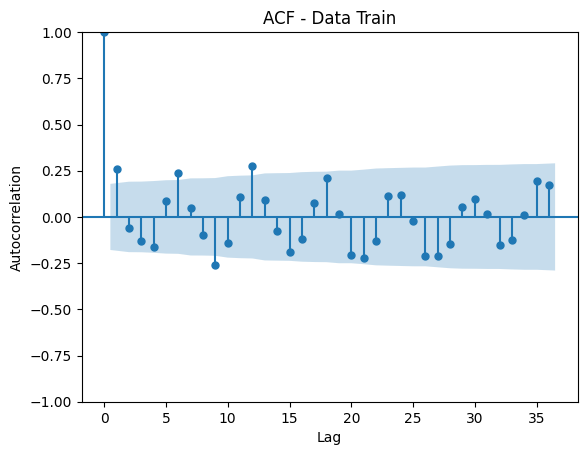

<Figure size 1000x400 with 0 Axes>

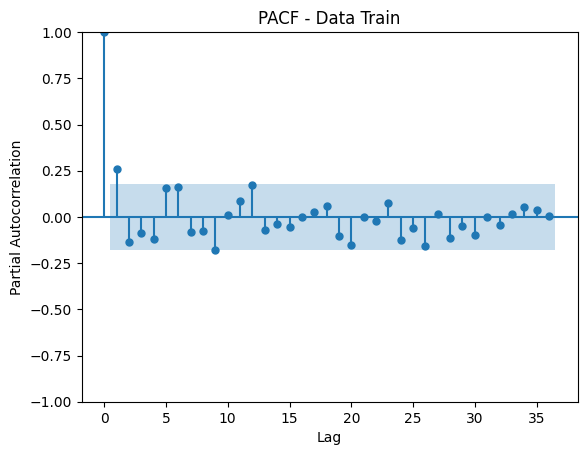

<Figure size 1000x400 with 0 Axes>

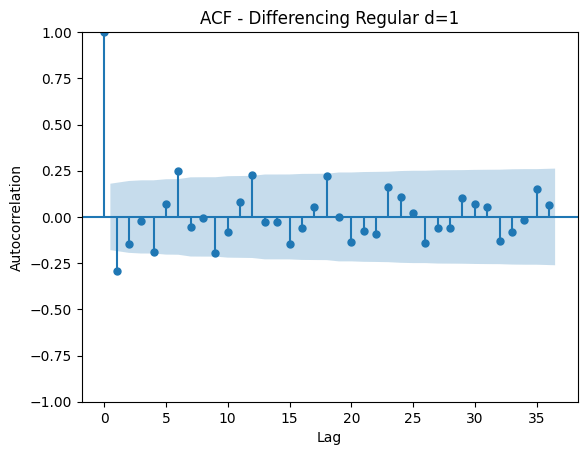

<Figure size 1000x400 with 0 Axes>

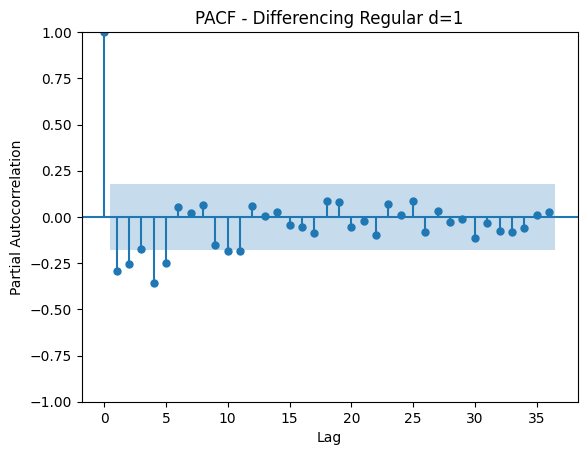

<Figure size 1000x400 with 0 Axes>

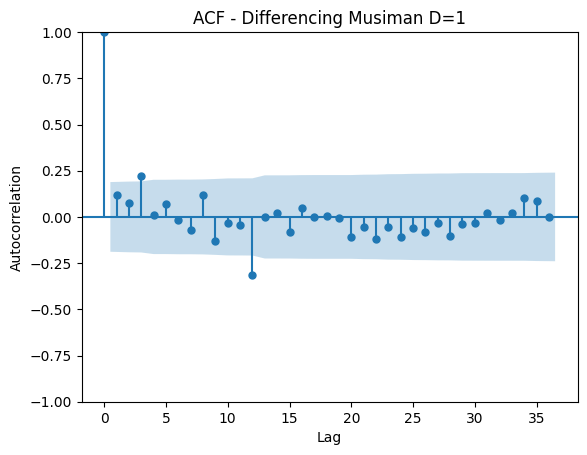

<Figure size 1000x400 with 0 Axes>

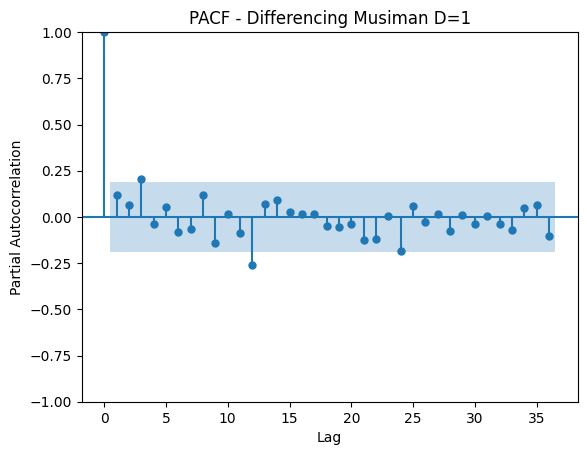

<Figure size 1000x400 with 0 Axes>

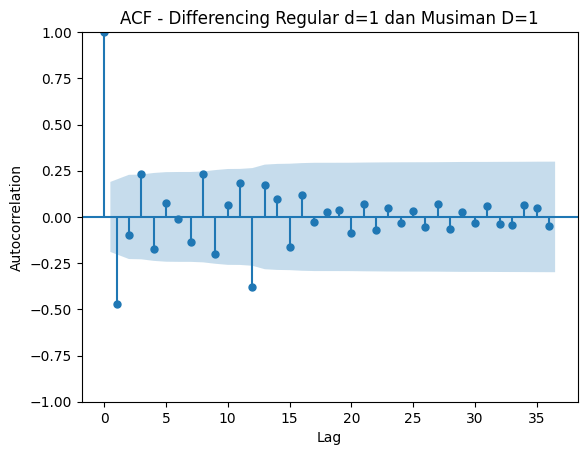

<Figure size 1000x400 with 0 Axes>

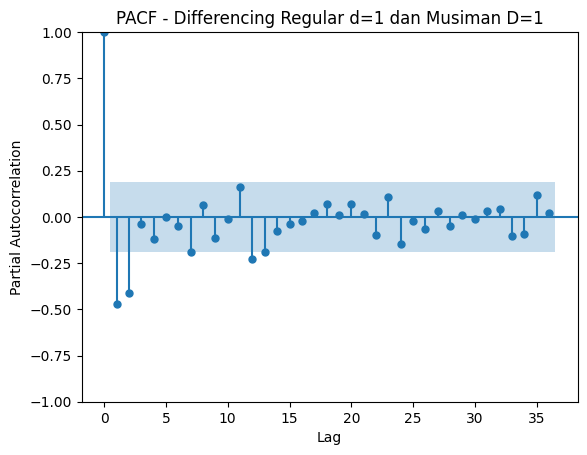

In [13]:
plot_acf_pacf(train, "Data Train", lags=36)
plot_acf_pacf(train_d1, "Differencing Regular d=1", lags=36)
plot_acf_pacf(train_D1, "Differencing Musiman D=1", lags=36)
plot_acf_pacf(train_d1_D1, "Differencing Regular d=1 dan Musiman D=1", lags=36)

# SARIMA Model Estimation

In [14]:
s = 12

results = []

p_values = range(0,3)
d_values = range(0,2)
q_values = range(0,3)

P_values = range(0, 2)
D_values = range(0, 2)
Q_values = range(0, 2)

for p in p_values:
    for d in d_values:
        for q in q_values:
            for P in P_values:
                for D in D_values:
                    for Q in Q_values:
                        order = (p,d,q)
                        seasonal_order = (P,D,Q,s)
                        if order == (0,0,0) and seasonal_order == (0,0,0,s):
                            continue
                        try:
                            model = SARIMAX(
                                df_train,
                                order=order,
                                seasonal_order=seasonal_order,
                                enforce_stationarity=False,
                                enforce_invertibility=False
                            )
                            fitted = model.fit(disp=False, maxiter=300)
                            forecast_test = fitted.get_forecast(steps=len(df_test))
                            pred_test = forecast_test.predicted_mean
                            pred_test.index = df_test.index

                            rmse = np.sqrt(mean_squared_error(df_test, pred_test))
                            mae = mean_absolute_error(df_test, pred_test)

                            lb_test = acorr_ljungbox(
                                fitted.resid.dropna(),
                                lags=[12],
                                return_df=True
                            )
                            lb_pvalue = lb_test["lb_pvalue"].iloc[0]
                            shapiro_pvalue = shapiro(fitted.resid.dropna()).pvalue

                            results.append({
                                "order": order,
                                "seasonal_order": seasonal_order,
                                "aic": fitted.aic,
                                "bic": fitted.bic,
                                "rmse": rmse,
                                "mae": mae,
                                "ljungbox_pvalue": lb_pvalue,
                                "shapiro_pvalue": shapiro_pvalue
                            })
                        except Exception as e:
                            pass

df_results = pd.DataFrame(results)
df_results = df_results.sort_values(["aic", "rmse"]).reset_index(drop=True)
print("Top model berdasarkan AIC:")
display(df_results.head(10))

C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\firma\AppData\Roaming\Python\Python311\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Top model berdasarkan AIC:


,order,seasonal_order,aic,bic,rmse,mae,ljungbox_pvalue,shapiro_pvalue
0,"(0, 1, 2)","(1, 0, 1, 12)",20.373349,33.595304,0.639352,0.465797,0.798092,0.362375
1,"(1, 1, 2)","(1, 0, 1, 12)",20.729758,36.596103,0.638203,0.464860,0.594194,0.079523
2,"(2, 1, 2)","(1, 0, 1, 12)",21.850661,40.361398,0.630007,0.461677,0.350863,0.237542
3,"(1, 0, 1)","(1, 0, 1, 12)",22.107752,35.424948,0.641932,0.478427,0.715713,0.070705
4,"(1, 0, 2)","(1, 0, 1, 12)",22.190505,38.114267,0.631175,0.470243,0.650245,0.051070
5,"(0, 1, 1)","(1, 0, 1, 12)",22.881202,33.497043,0.638522,0.465540,0.739208,0.418195
6,"(2, 0, 2)","(1, 0, 1, 12)",23.838796,42.416519,0.626912,0.468576,0.666467,0.037578
7,"(1, 0, 0)","(1, 0, 1, 12)",23.943081,34.634396,0.641041,0.469731,0.834195,0.000127
8,"(2, 0, 1)","(1, 0, 1, 12)",24.099948,40.080582,0.642606,0.478844,0.722488,0.070128
9,"(1, 1, 1)","(1, 0, 1, 12)",24.174088,37.443890,0.638024,0.457809,0.843301,0.020084


In [15]:
df_results.to_csv("top_model_sarima.csv", index=False)

models = df_results[
    (df_results["ljungbox_pvalue"] > 0.05) & (df_results["shapiro_pvalue"] > 0.05)
].copy()

print(f"Jumlah model yang lolos diagnostic checking: {len(models)}")
if len(models) > 0:
    best_model = models.sort_values(["rmse", "aic"]).iloc[0]
else:
    best_model = df_results.iloc[0]

print("Model SARIMA terbaik")
print(best_model)

Jumlah model yang lolos diagnostic checking: 33
Model SARIMA terbaik
order                  (2, 0, 2)
seasonal_order     (1, 1, 0, 12)
aic                    41.009165
bic                    56.268934
rmse                    0.590769
mae                     0.458016
ljungbox_pvalue         0.773102
shapiro_pvalue          0.081517
Name: 71, dtype: object


## Fit model

In [16]:
best_order = best_model["order"]
best_seasonal_order = best_model["seasonal_order"]

best_model_train = SARIMAX(
    df_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

best_fitted_train = best_model_train.fit(disp=False, maxiter=300)
print(best_fitted_train.summary())

                                      SARIMAX Results                                      
Dep. Variable:                             inflasi   No. Observations:                  120
Model:             SARIMAX(2, 0, 2)x(1, 1, [], 12)   Log Likelihood                 -14.505
Date:                             Mon, 22 Jun 2026   AIC                             41.009
Time:                                     18:44:43   BIC                             56.269
Sample:                                 01-01-2015   HQIC                            47.173
                                      - 12-01-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0383      0.443      2.344      0.019       0.170       1.906
ar.L2         -0.2852      

## Evaluasi out-sample

In [17]:
forecast_test = best_fitted_train.get_forecast(steps=len(df_test))
pred_test = forecast_test.predicted_mean
pred_test.index = df_test.index

df_eval = pd.DataFrame({
    "actual": df_test,
    "forecast": pred_test
})
df_eval["error"] = df_eval["actual"] - df_eval["forecast"]
df_eval["abs_error"] = df_eval["error"].abs()
df_eval["squared_error"] = df_eval["error"] ** 2

rmse = np.sqrt(mean_squared_error(df_eval["actual"], df_eval["forecast"]))
mae = mean_absolute_error(df_eval["actual"], df_eval["forecast"])

display(df_eval)
print("RMSE:", rmse)
print("MAE :", mae)

df_eval.to_csv("evaluasi_outsample_2025.csv")

,actual,forecast,error,abs_error,squared_error
tanggal,,,,,
2025-01-01,-0.76,0.139526,-0.899526,0.899526,0.809147
2025-02-01,-0.48,0.288459,-0.768459,0.768459,0.590529
2025-03-01,1.65,0.392342,1.257658,1.257658,1.581704
2025-04-01,1.17,0.290481,0.879519,0.879519,0.773554
2025-05-01,-0.37,0.024343,-0.394343,0.394343,0.155506
2025-06-01,0.19,0.012332,0.177668,0.177668,0.031566
2025-07-01,0.30,-0.021038,0.321038,0.321038,0.103065
2025-08-01,-0.08,-0.024623,-0.055377,0.055377,0.003067
2025-09-01,0.21,0.005158,0.204842,0.204842,0.041960


RMSE: 0.5907692285495699
MAE : 0.4580158549856456


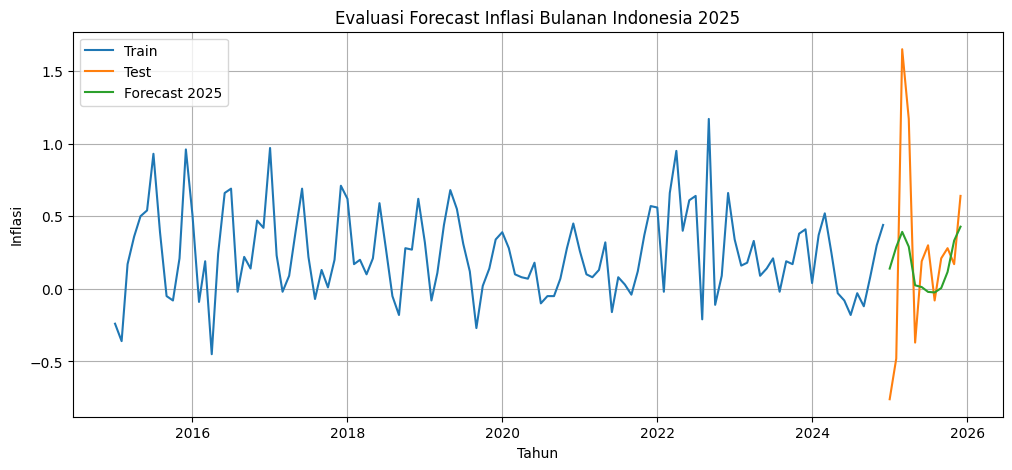

In [18]:
plt.figure(figsize=(12, 5))
plt.plot(df_train.index, df_train, label="Train")
plt.plot(df_test.index, df_test, label="Test")
plt.plot(pred_test.index, pred_test, label="Forecast 2025")
plt.title("Evaluasi Forecast Inflasi Bulanan Indonesia 2025")
plt.xlabel("Tahun")
plt.ylabel("Inflasi")
plt.legend()
plt.grid(True)
plt.show()

# Diagnostic Checking

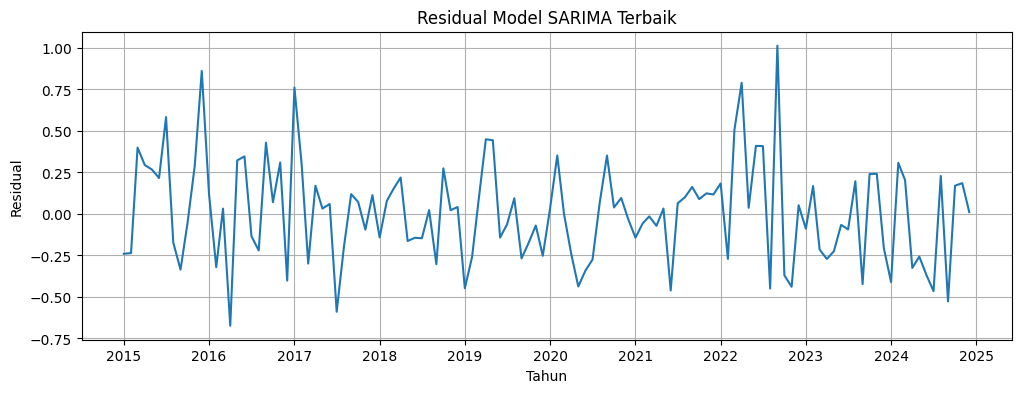

<Figure size 1000x400 with 0 Axes>

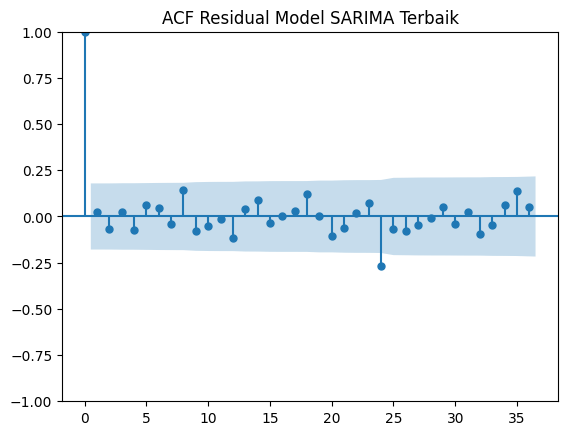

Ljung-Box Test:
      lb_stat  lb_pvalue
12   8.152505   0.773102
24  26.152413   0.345477
Shapiro-Wilk Test
Statistic: 0.9806311311078403
p-value  : 0.08151736711633988


In [19]:
residual = best_fitted_train.resid.dropna()

plt.figure(figsize=(12, 4))
plt.plot(residual)
plt.title("Residual Model SARIMA Terbaik")
plt.xlabel("Tahun")
plt.ylabel("Residual")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plot_acf(residual, lags=36)
plt.title("ACF Residual Model SARIMA Terbaik")
plt.show()

lb = acorr_ljungbox(residual, lags=[12, 24], return_df=True)
print("Ljung-Box Test:")
print(lb)

shapiro_stat, shapiro_p = shapiro(residual)
print("Shapiro-Wilk Test")
print("Statistic:", shapiro_stat)
print("p-value  :", shapiro_p)

# Forecasting

In [20]:
final_model = SARIMAX(
    y,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_fitted = final_model.fit(disp=False, maxiter=300)

forecast_2026 = final_fitted.get_forecast(steps=12)
forecast_mean = forecast_2026.predicted_mean
forecast_ci = forecast_2026.conf_int(alpha=0.05)

df_forecast = pd.DataFrame({
    "forecast": forecast_mean,
    "lower_95": forecast_ci.iloc[:, 0],
    "upper_95": forecast_ci.iloc[:, 1]
})

display(df_forecast)
df_forecast.to_csv("forecast_inflasi_2026_sarima.csv")

,forecast,lower_95,upper_95
2026-01-01,-0.422975,-1.080806,0.234856
2026-02-01,-0.200482,-0.871235,0.470271
2026-03-01,1.270994,0.599524,1.942463
2026-04-01,0.844405,0.171999,1.516812
2026-05-01,-0.247101,-0.919551,0.425349
2026-06-01,0.094626,-0.577893,0.767145
2026-07-01,0.133539,-0.538982,0.806061
2026-08-01,-0.062819,-0.735345,0.609708
2026-09-01,0.095087,-0.577440,0.767613
2026-10-01,0.210101,-0.462426,0.882629


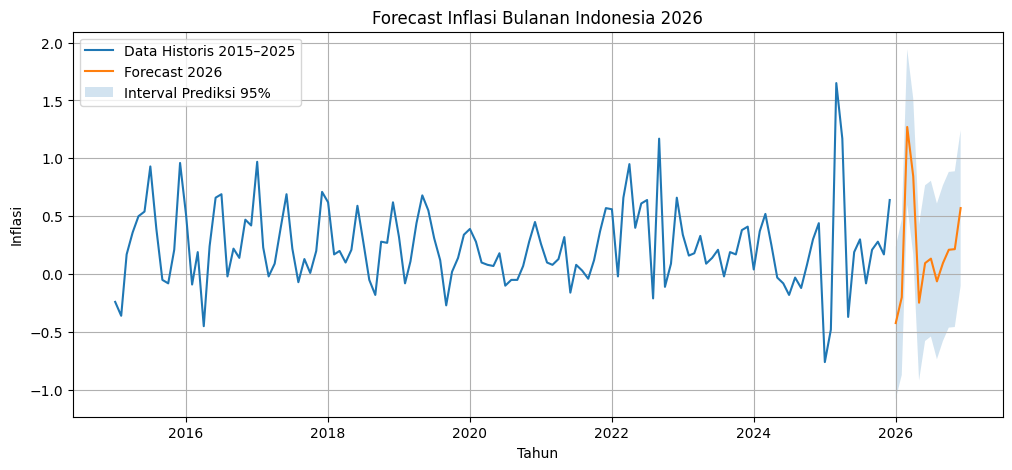

In [21]:
plt.figure(figsize=(12, 5))

plt.plot(y.index, y, label="Data Historis 2015–2025")
plt.plot(df_forecast.index, df_forecast["forecast"], label="Forecast 2026")

plt.fill_between(
    df_forecast.index,
    df_forecast["lower_95"],
    df_forecast["upper_95"],
    alpha=0.2,
    label="Interval Prediksi 95%"
)

plt.title("Forecast Inflasi Bulanan Indonesia 2026")
plt.xlabel("Tahun")
plt.ylabel("Inflasi")
plt.legend()
plt.grid(True)
plt.show()

# Compare 2026 actual with 2026 forecast

In [22]:
df_actual_2026 = df_all[
    (df_all["tanggal"] >= "2026-01-01") & (df_all["tanggal"] <= "2026-12-01")
].copy()

df_actual_2026 = df_actual_2026.set_index("tanggal").sort_index()["inflasi"].dropna()
forecast_5bulan = df_forecast.loc[df_actual_2026.index, "forecast"]
df_compare = pd.DataFrame({
    "aktual_2026": df_actual_2026,
    "forecast_2026": forecast_5bulan
})

df_compare["selisih"] = df_compare["aktual_2026"] - df_compare["forecast_2026"]
df_compare["abs_selisih"] = df_compare["selisih"].abs()
df_compare

,aktual_2026,forecast_2026,selisih,abs_selisih
tanggal,,,,
2026-01-01,-0.15,-0.422975,0.272975,0.272975
2026-02-01,0.68,-0.200482,0.880482,0.880482
2026-03-01,0.41,1.270994,-0.860994,0.860994
2026-04-01,0.13,0.844405,-0.714405,0.714405
2026-05-01,0.28,-0.247101,0.527101,0.527101


In [23]:
rmse_2026 = np.sqrt(mean_squared_error(df_compare["aktual_2026"], df_compare["forecast_2026"]))
mae_2026 = mean_absolute_error(df_compare["aktual_2026"], df_compare["forecast_2026"])

print("RMSE 5 bulan 2026:", rmse_2026)
print("MAE 5 bulan 2026 :", mae_2026)

RMSE 5 bulan 2026: 0.6898237539354244
MAE 5 bulan 2026 : 0.6511914312846128


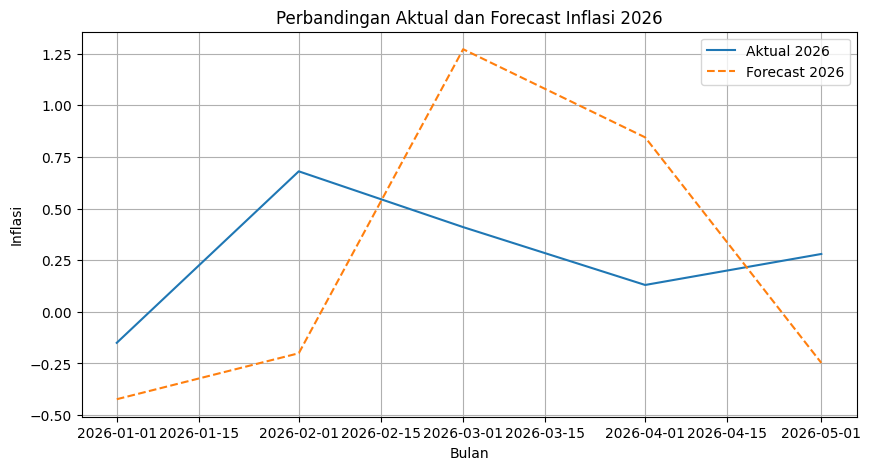

In [24]:
plt.figure(figsize=(10, 5))

plt.plot(df_compare.index, df_compare["aktual_2026"], label="Aktual 2026")
plt.plot(df_compare.index, df_compare["forecast_2026"], linestyle="--", label="Forecast 2026")

plt.title("Perbandingan Aktual dan Forecast Inflasi 2026")
plt.xlabel("Bulan")
plt.ylabel("Inflasi")
plt.legend()
plt.grid(True)
plt.show()

# JAWA TIMUR